# Data exploratory

In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
import plotly.graph_objs as go 
import plotly.offline as py 
import plotly.io as pio
# Use the external browser renderer to avoid nbformat-based mime rendering in some notebook kernels
pio.renderers.default = 'browser'
import math
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = 'all'

In [30]:
print("\nTransaction features: \n")
df_txs_features = pd.read_csv("dataset/txs_features.csv")
df_txs_features

print("\nTransaction classes: \n")
df_txs_classes = pd.read_csv("dataset/txs_classes.csv")
df_txs_classes

print("\nTransaction-Transaction edgelist: \n")
df_txs_edgelist = pd.read_csv("dataset/txs_edgelist.csv")
df_txs_edgelist


Transaction features: 



,txId,Time step,Local_feature_1,Local_feature_2,Local_feature_3,Local_feature_4,Local_feature_5,Local_feature_6,Local_feature_7,Local_feature_8,...,in_BTC_min,in_BTC_max,in_BTC_mean,in_BTC_median,in_BTC_total,out_BTC_min,out_BTC_max,out_BTC_mean,out_BTC_median,out_BTC_total
0,3321,1,-0.169615,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.160199,...,0.534072,0.534072,0.534072,0.534072,0.534072,1.668990e-01,0.367074,0.266986,0.266986,0.533972
1,11108,1,-0.137586,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.127429,...,5.611878,5.611878,5.611878,5.611878,5.611878,5.861940e-01,5.025584,2.805889,2.805889,5.611778
2,51816,1,-0.170103,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.160699,...,0.456608,0.456608,0.456608,0.456608,0.456608,2.279902e-01,0.228518,0.228254,0.228254,0.456508
3,68869,1,-0.114267,-0.184668,-1.201369,0.028105,-0.043875,-0.113002,0.547008,-0.161652,...,0.308900,8.000000,3.102967,1.000000,9.308900,1.229000e+00,8.079800,4.654400,4.654400,9.308800
4,89273,1,5.202107,-0.210553,-1.756361,-0.121970,260.090707,-0.113002,-0.061584,5.335864,...,852.164680,852.164680,852.164680,852.164680,852.164680,1.300000e-07,41.264036,0.065016,0.000441,852.164680
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
203764,158304003,49,-0.165622,-0.139563,1.018602,-0.121970,-0.043875,-0.113002,-0.061584,-0.156113,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
203765,158303998,49,-0.167040,-0.139563,1.018602,-0.121970,-0.043875,-0.113002,-0.061584,-0.157564,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
203766,158303966,49,-0.167040,-0.139563,1.018602,-0.121970,-0.043875,-0.113002,-0.061584,-0.157564,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
203767,161526077,49,-0.172212,-0.139573,1.018602,-0.121970,-0.043875,-0.113002,-0.061584,-0.162856,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN



Transaction classes: 



,txId,class
0,3321,3
1,11108,3
2,51816,3
3,68869,2
4,89273,2
...,...,...
203764,158304003,3
203765,158303998,3
203766,158303966,3
203767,161526077,3



Transaction-Transaction edgelist: 



,txId1,txId2
0,230425980,5530458
1,232022460,232438397
2,230460314,230459870
3,230333930,230595899
4,232013274,232029206
...,...,...
234350,158365409,157930723
234351,188708874,188708879
234352,157659064,157659046
234353,87414554,106877725


In [31]:
df_txs_features.insert(loc=2, column='class', value=df_txs_classes['class'])
df_txs_features['class'].value_counts()

class
3    157205
2     42019
1      4545
Name: count, dtype: int64

<BarContainer object of 3 artists>

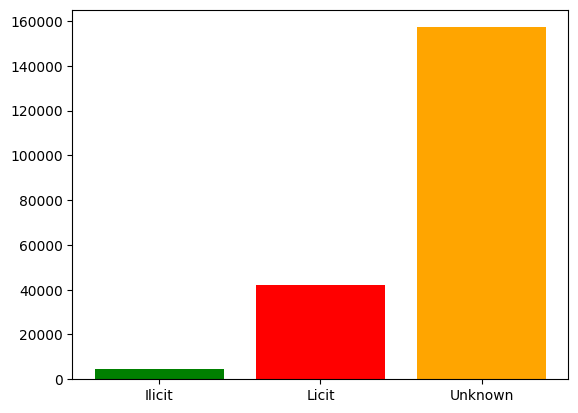

In [32]:
txs_by_class = df_txs_features.groupby('class').count()
plt.bar(['Ilicit', 'Licit', 'Unknown'], txs_by_class['txId'].values, color=['g', 'r', 'orange'] )

Text(0.5, 1.0, 'Number of transactions by time step')

C:\Users\alast\AppData\Local\Temp\ipykernel_25416\897365904.py:12: UserWarning:

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.



Text(0.5, 0, 'Time step')

Text(0, 0.5, 'Number of transactions')

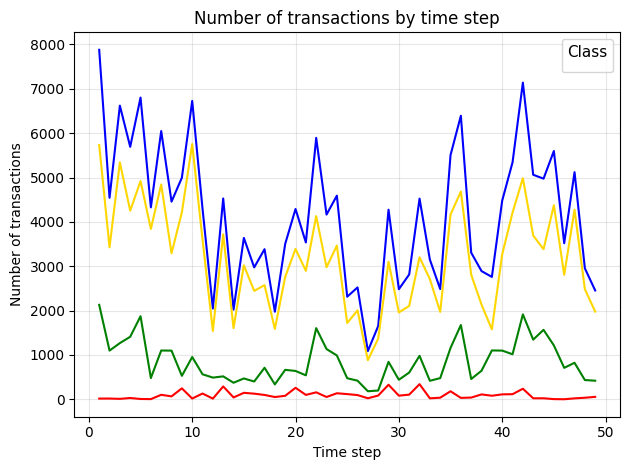

In [33]:
total_txs = df_txs_features.groupby('Time step').count()
illicit_txs = df_txs_features[df_txs_features['class']==1].groupby('Time step').count()
licit_txs = df_txs_features[df_txs_features['class']==2].groupby('Time step').count()
unknown_txs = df_txs_features[df_txs_features['class']==3].groupby('Time step').count()

plt.title('Number of transactions by time step')
plt.plot(total_txs['txId'], color='blue')
plt.plot(illicit_txs['txId'], color='red')
plt.plot(licit_txs['txId'], color='green')
plt.plot(unknown_txs['txId'], color='gold')

plt.legend(loc='upper right', frameon=True, fontsize=10, title='Class', title_fontsize=11)
plt.xlabel('Time step')
plt.ylabel('Number of transactions')
plt.grid(alpha=0.3)
plt.tight_layout()
     

In [34]:
grouped_class = df_txs_features[['Time step','class']].groupby(['Time step','class']).size().to_frame().reset_index()

timesteps = list(range(1,50))

fig = go.Figure(data = [
    go.Bar(name="Unknown (unlabelled)",x=timesteps,y=grouped_class[grouped_class['class'] == 3][0],marker = dict(color = 'orange', line = dict(color = 'orange',width=1))),
    go.Bar(name="Licit (non-fraud)",x=timesteps,y=grouped_class[grouped_class['class'] == 2][0],marker = dict(color = 'green', line = dict(color = 'green',width=1))),
    go.Bar(name="Illicit (fraud)",x=timesteps,y=grouped_class[grouped_class['class'] == 1][0],marker = dict(color = 'red', line = dict(color = 'red',width=1)))
])

fig.update_layout(barmode='stack')
     

In [35]:
unknown_count = grouped_class[grouped_class['class'] == 3]
illicit_count = grouped_class[grouped_class['class'] == 1]
licit_count = grouped_class[grouped_class['class'] == 2]

frames = [unknown_count, illicit_count, licit_count]
df_count_distribution = pd.concat(frames)
df_count_distribution.rename(columns={0: 'counts'}).sort_values('Time step')

,Time step,class,counts
2,1,3,5733
0,1,1,17
1,1,2,2130
5,2,3,3427
3,2,1,18
...,...,...,...
143,48,3,2483
141,48,1,36
144,49,1,56
146,49,3,1978


# Model training

In [36]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, classification_report
from sklearn.preprocessing import StandardScaler,MinMaxScaler
from torch_geometric.data import Data
from torch_geometric.nn import GCNConv, GATConv, TransformerConv

In [37]:
# 1) Prepare node features X, labels y, and masks
#    - keep only numeric columns for X (drop identifiers + label)
drop_cols = {'txId','Time step','class'}
feat_cols = [c for c in df_txs_features.columns if c not in drop_cols and pd.api.types.is_numeric_dtype(df_txs_features[c])]
assert len(feat_cols) > 0, "No numeric feature columns found for X"

# Map txId -> node index
txid_to_idx = {tx_id: i for i, tx_id in enumerate(df_txs_features['txId'].values)}
num_nodes = len(txid_to_idx)

# X - Handle NaN values (do NOT fit scaler yet)
X_raw = df_txs_features[feat_cols].values
# Replace NaN with column median
X_filled = np.where(np.isnan(X_raw), np.nanmedian(X_raw, axis=0, keepdims=True), X_raw)

# y (binary for labeled nodes): map {Illicit=1, Licit=0}; Unknown=ignored (mask=False)
label_series = df_txs_features['class']  # 1=illicit, 2=licit, 3=unknown
is_labeled = label_series.isin([1,2]).values
# build numpy label array for convenience
y_np = np.full(num_nodes, -1, dtype=int)
y_np[label_series.values == 1] = 1
y_np[label_series.values == 2] = 0

# --- Use temporal split: TRAIN timesteps 1..34, TEST timesteps 35..49
# prefer df_txs_features_selected if present (you may have used it earlier for feature selection)
df_src = globals().get('df_txs_features_selected', df_txs_features)

# Create lists of transaction ids for train/test (exclude unknown class=3)
train_txids = df_src.loc[(df_src['Time step'] >= 1) & (df_src['Time step'] <= 34) & (df_src['class'] != 3), 'txId'].values
test_txids  = df_src.loc[(df_src['Time step'] >= 35) & (df_src['Time step'] <= 49) & (df_src['class'] != 3), 'txId'].values

# Build DataFrames for train/test features (drop identifiers and meta columns)
X_training_timesteps = df_src[df_src['txId'].isin(train_txids)].copy()
X_training_timesteps = X_training_timesteps.drop(columns=['txId','class','Time step'])
X_testing_timesteps  = df_src[df_src['txId'].isin(test_txids)].copy()
X_testing_timesteps = X_testing_timesteps.drop(columns=['txId','class','Time step'])

# Prepare labels for train/test (map class 2 -> 0 (licit), class 1 -> 1 (illicit))
y_training_timesteps = df_src[df_src['txId'].isin(train_txids)][['class']].copy()
y_training_timesteps = y_training_timesteps['class'].apply(lambda x: 0 if x == 2 else 1)
y_testing_timesteps  = df_src[df_src['txId'].isin(test_txids)][['class']].copy()
y_testing_timesteps = y_testing_timesteps['class'].apply(lambda x: 0 if x == 2 else 1)

# Expose variables for downstream code: X_train/X_test (pandas), y_train/y_test (Series)
X_train = X_training_timesteps
X_test  = X_testing_timesteps
y_train = y_training_timesteps
y_test  = y_testing_timesteps

# Map txIds -> node indices (for building masks and global arrays)
train_idx = [txid_to_idx[t] for t in train_txids if t in txid_to_idx]
test_idx  = [txid_to_idx[t] for t in test_txids  if t in txid_to_idx]

# Fit scaler ONLY on training nodes to avoid leakage
scaler = MinMaxScaler()
if len(train_idx) > 0:
    scaler.fit(X_filled[train_idx])
    X_normalized = scaler.transform(X_filled)
else:
    # fallback: fit on all if no train indices (shouldn't happen)
    X_normalized = scaler.fit_transform(X_filled)

X = torch.tensor(X_normalized, dtype=torch.float)

# Build edge_index (only keep edges where both endpoints exist)
edges_df = df_txs_edgelist[['txId1','txId2']].copy()
edges_df = edges_df[edges_df['txId1'].isin(txid_to_idx) & edges_df['txId2'].isin(txid_to_idx)]

src = edges_df['txId1'].map(txid_to_idx).values
dst = edges_df['txId2'].map(txid_to_idx).values
edge_index = torch.tensor([src, dst], dtype=torch.long)
# (optional) make undirected by adding reverse edges
edge_index = torch.cat([edge_index, edge_index.flip(0)], dim=1)

# Build y tensor
y = torch.tensor(y_np, dtype=torch.long)

# Build masks for PyG (train/test only, no validation)
train_mask = torch.zeros(num_nodes, dtype=torch.bool)
test_mask  = torch.zeros(num_nodes, dtype=torch.bool)

if len(train_idx) > 0:
    train_mask[torch.tensor(train_idx, dtype=torch.long)] = True
if len(test_idx) > 0:
    test_mask[torch.tensor(test_idx, dtype=torch.long)] = True

# Build PyG Data object
from torch_geometric.data import Data

data = Data(x=X, edge_index=edge_index, y=y)
data.train_mask = train_mask
data.test_mask  = test_mask

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
data = data.to(device)

input_dim = data.num_features
hidden_dim = 64
num_classes = 2  # illicit vs licit

print(f"Dataset prepared:")
print(f"  Total nodes: {num_nodes}")
print(f"  Train samples: {train_mask.sum().item()}")
print(f"  Test samples: {test_mask.sum().item()}")
print(f"  Features: {input_dim}")
print(f"  Device: {device}")


,feature_range,"(0, ...)"
,copy,True
,clip,False


In [ ]:
# === Model definitions, training and evaluation ===
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.metrics import accuracy_score, f1_score, classification_report

# Model definitions
class GCN(nn.Module):
    def __init__(self, in_dim, hid, out_dim, dropout=0.5):
        super().__init__()
        from torch_geometric.nn import GCNConv
        self.conv1 = GCNConv(in_dim, hid, add_self_loops=True, normalize=True)
        self.conv2 = GCNConv(hid, out_dim, add_self_loops=True, normalize=True)
        self.dropout = dropout
    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = self.conv2(x, edge_index)
        return x

class GAT(nn.Module):
    def __init__(self, in_dim, hid, out_dim, heads=4, dropout=0.5):
        super().__init__()
        from torch_geometric.nn import GATConv
        self.gat1 = GATConv(in_dim, hid, heads=heads, dropout=dropout)
        self.gat2 = GATConv(hid*heads, out_dim, heads=1, concat=False, dropout=dropout)
        self.dropout = dropout
    def forward(self, x, edge_index):
        x = self.gat1(x, edge_index)
        x = F.elu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = self.gat2(x, edge_index)
        return x

class GraphTransformer(nn.Module):
    def __init__(self, in_dim, hid, out_dim, heads=4, dropout=0.5):
        super().__init__()
        from torch_geometric.nn import TransformerConv
        self.trans1 = TransformerConv(in_dim, hid, heads=heads, dropout=dropout, beta=True)
        self.trans2 = TransformerConv(hid*heads, out_dim, heads=1, concat=False, dropout=dropout, beta=True)
        self.dropout = dropout
    def forward(self, x, edge_index):
        x = self.trans1(x, edge_index)
        x = F.elu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = self.trans2(x, edge_index)
        return x

# Training/eval helpers

def train_model(model, data, max_epochs=200, lr=1e-3, weight_decay=5e-4, verbose_every=20):
    # Move model to same device as data
    model = model.to(data.x.device)
    opt = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    loss_history = []

    # class weights (avoid division by zero)
    train_labels = data.y[data.train_mask].cpu().numpy()
    class_counts = np.bincount(train_labels, minlength=2)
    class_counts = np.clip(class_counts, a_min=1, a_max=None)
    class_weights = torch.tensor([1.0 / class_counts[0], 1.0 / class_counts[1]], dtype=torch.float).to(data.x.device)

    for epoch in range(1, max_epochs+1):
        model.train()
        opt.zero_grad()
        out = model(data.x, data.edge_index)
        loss = F.cross_entropy(out[data.train_mask], data.y[data.train_mask], weight=class_weights)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        opt.step()
        loss_history.append(loss.item())

        if epoch % verbose_every == 0 or epoch == max_epochs:
            train_acc, train_f1 = eval_on_mask(model, data, data.train_mask)
            print(f"[Epoch {epoch:03d}] loss={loss.item():.4f}  train_acc={train_acc:.4f}  train_f1={train_f1:.4f}")

    return model, loss_history

@torch.no_grad()
def eval_on_mask(model, data, mask):
    model.eval()
    logits = model(data.x, data.edge_index)
    probs = F.softmax(logits[mask], dim=-1)
    preds = probs.argmax(dim=-1).cpu().numpy()
    true = data.y[mask].cpu().numpy()
    if len(true) == 0:
        return 0.0, 0.0
    acc = accuracy_score(true, preds)
    f1 = f1_score(true, preds, average='binary')
    return acc, f1

@torch.no_grad()
def report(model, data, mask, name=""):
    model.eval()
    logits = model(data.x, data.edge_index)
    preds = logits[mask].argmax(dim=-1).cpu().numpy()
    true = data.y[mask].cpu().numpy()
    print(f"\n{name} Report")
    if len(true) == 0:
        print("No samples in mask.")
        return
    print(classification_report(true, preds, target_names=["Licit(0)", "Illicit(1)"]))

# Train GCN/GAT/Transformer if data/masks exist
if 'data' in globals():
    print("\nTraining models: GCN, GAT, GraphTransformer")
    print(f"Train samples: {train_mask.sum().item()}, Test samples: {test_mask.sum().item()}")
    print(f"Device: {device}")
    
    gcn = GCN(input_dim, hidden_dim, num_classes, dropout=0.5)
    print("\n" + "="*60)
    print("Training GCN Model")
    print("="*60)
    gcn, gcn_loss_history = train_model(gcn, data, max_epochs=200, lr=0.005, weight_decay=5e-4, verbose_every=20)
    print("\n== GCN Performance ==")
    ta, tf1 = eval_on_mask(gcn, data, data.test_mask)
    print(f"Test acc={ta:.4f}  f1={tf1:.4f}")
    report(gcn, data, data.test_mask, name="GCN Test")

    gat = GAT(input_dim, hidden_dim, num_classes, heads=4, dropout=0.5)
    print("\n" + "="*60)
    print("Training GAT Model")
    print("="*60)
    gat, gat_loss_history = train_model(gat, data, max_epochs=200, lr=0.005, weight_decay=5e-4, verbose_every=20)
    print("\n== GAT Performance ==")
    ta, tf1 = eval_on_mask(gat, data, data.test_mask)
    print(f"Test acc={ta:.4f}  f1={tf1:.4f}")
    report(gat, data, data.test_mask, name="GAT Test")

    transformer = GraphTransformer(input_dim, hidden_dim, num_classes, heads=4, dropout=0.5)
    print("\n" + "="*60)
    print("Training Graph Transformer Model")
    print("="*60)
    transformer, transformer_loss_history = train_model(transformer, data, max_epochs=200, lr=0.005, weight_decay=5e-4, verbose_every=20)
    print("\n== Graph Transformer Performance ==")
    ta, tf1 = eval_on_mask(transformer, data, data.test_mask)
    print(f"Test acc={ta:.4f}  f1={tf1:.4f}")
    report(transformer, data, data.test_mask, name="Graph Transformer Test")



Training models: GCN, GAT, GraphTransformer
Train samples: 23915, Val samples: 5979, Test samples: 16670
Device: cuda

Training GCN Model
[Epoch 020] loss=0.4214  val_acc=0.8001  val_f1=0.5136
[Epoch 020] loss=0.4214  val_acc=0.8001  val_f1=0.5136
[Epoch 040] loss=0.3389  val_acc=0.8272  val_f1=0.5483
[Epoch 040] loss=0.3389  val_acc=0.8272  val_f1=0.5483
[Epoch 060] loss=0.3132  val_acc=0.8460  val_f1=0.5750
[Epoch 060] loss=0.3132  val_acc=0.8460  val_f1=0.5750
[Epoch 080] loss=0.2977  val_acc=0.8542  val_f1=0.5891
[Epoch 080] loss=0.2977  val_acc=0.8542  val_f1=0.5891
[Epoch 100] loss=0.2846  val_acc=0.8654  val_f1=0.6071
[Epoch 100] loss=0.2846  val_acc=0.8654  val_f1=0.6071
[Epoch 120] loss=0.2706  val_acc=0.8695  val_f1=0.6158
[Epoch 120] loss=0.2706  val_acc=0.8695  val_f1=0.6158
[Epoch 140] loss=0.2624  val_acc=0.8766  val_f1=0.6291
[Epoch 140] loss=0.2624  val_acc=0.8766  val_f1=0.6291
[Epoch 160] loss=0.2562  val_acc=0.8821  val_f1=0.6412
[Epoch 160] loss=0.2562  val_acc=0.8

<Axes: >

Text(0.5, 36.72222222222221, 'Predicted')

Text(220.72222222222223, 0.5, 'True')

Text(0.5, 1.0, 'GCN: Confusion Matrix')

<Axes: >

Text(0.5, 36.72222222222221, 'Predicted')

Text(767.7810457516341, 0.5, 'True')

Text(0.5, 1.0, 'GAT: Confusion Matrix')

<Axes: >

Text(0.5, 36.72222222222221, 'Predicted')

Text(1314.8398692810458, 0.5, 'True')

Text(0.5, 1.0, 'Graph Transformer: Confusion Matrix')

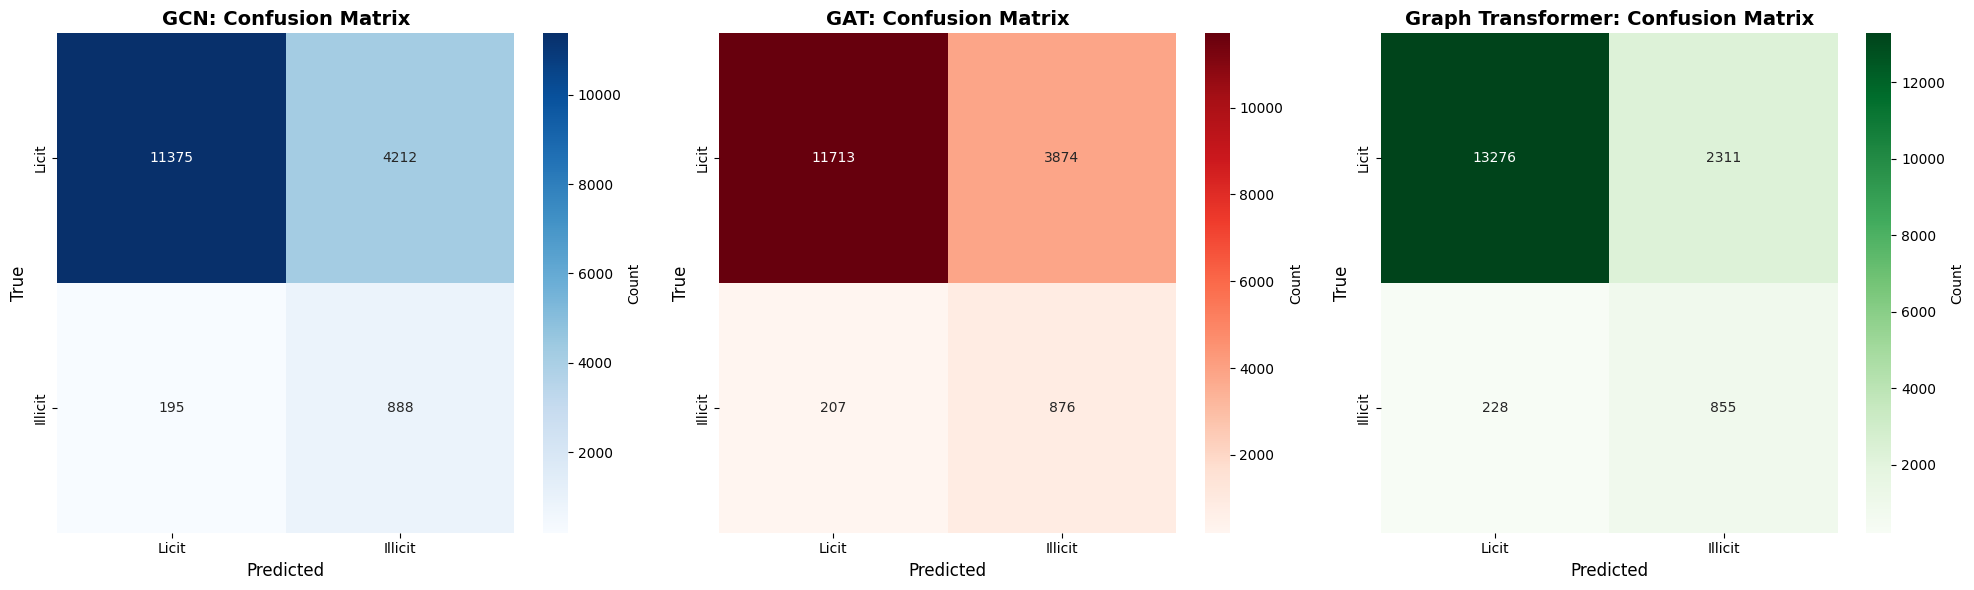


=== GCN Confusion Matrix ===
True Negatives (Licit predicted as Licit): 11375
False Positives (Licit predicted as Illicit): 4212
False Negatives (Illicit predicted as Licit): 195
True Positives (Illicit predicted as Illicit): 888

=== GAT Confusion Matrix ===
True Negatives (Licit predicted as Licit): 11713
False Positives (Licit predicted as Illicit): 3874
False Negatives (Illicit predicted as Licit): 207
True Positives (Illicit predicted as Illicit): 876

=== Graph Transformer Confusion Matrix ===
True Negatives (Licit predicted as Licit): 13276
False Positives (Licit predicted as Illicit): 2311
False Negatives (Illicit predicted as Licit): 228
True Positives (Illicit predicted as Illicit): 855


In [39]:
from sklearn.metrics import confusion_matrix

# Generate confusion matrices
@torch.no_grad()
def get_confusion_matrix(model, data, mask):
    model.eval()
    logits = model(data.x, data.edge_index)
    preds = logits[mask].argmax(dim=-1).cpu().numpy()
    true = data.y[mask].cpu().numpy()
    return confusion_matrix(true, preds)

gcn_cm = get_confusion_matrix(gcn, data, data.test_mask)
gat_cm = get_confusion_matrix(gat, data, data.test_mask)
transformer_cm = get_confusion_matrix(transformer, data, data.test_mask)

# Plot confusion matrices
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(20, 6))

# GCN Confusion Matrix
sns.heatmap(gcn_cm, annot=True, fmt='d', cmap='Blues', ax=ax1, 
            xticklabels=['Licit', 'Illicit'], 
            yticklabels=['Licit', 'Illicit'],
            cbar_kws={'label': 'Count'})
ax1.set_xlabel('Predicted', fontsize=12)
ax1.set_ylabel('True', fontsize=12)
ax1.set_title('GCN: Confusion Matrix', fontsize=14, fontweight='bold')

# GAT Confusion Matrix
sns.heatmap(gat_cm, annot=True, fmt='d', cmap='Reds', ax=ax2,
            xticklabels=['Licit', 'Illicit'], 
            yticklabels=['Licit', 'Illicit'],
            cbar_kws={'label': 'Count'})
ax2.set_xlabel('Predicted', fontsize=12)
ax2.set_ylabel('True', fontsize=12)
ax2.set_title('GAT: Confusion Matrix', fontsize=14, fontweight='bold')

# Transformer Confusion Matrix
sns.heatmap(transformer_cm, annot=True, fmt='d', cmap='Greens', ax=ax3,
            xticklabels=['Licit', 'Illicit'], 
            yticklabels=['Licit', 'Illicit'],
            cbar_kws={'label': 'Count'})
ax3.set_xlabel('Predicted', fontsize=12)
ax3.set_ylabel('True', fontsize=12)
ax3.set_title('Graph Transformer: Confusion Matrix', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

# Print additional metrics
print("\n=== GCN Confusion Matrix ===")
print(f"True Negatives (Licit predicted as Licit): {gcn_cm[0,0]}")
print(f"False Positives (Licit predicted as Illicit): {gcn_cm[0,1]}")
print(f"False Negatives (Illicit predicted as Licit): {gcn_cm[1,0]}")
print(f"True Positives (Illicit predicted as Illicit): {gcn_cm[1,1]}")

print("\n=== GAT Confusion Matrix ===")
print(f"True Negatives (Licit predicted as Licit): {gat_cm[0,0]}")
print(f"False Positives (Licit predicted as Illicit): {gat_cm[0,1]}")
print(f"False Negatives (Illicit predicted as Licit): {gat_cm[1,0]}")
print(f"True Positives (Illicit predicted as Illicit): {gat_cm[1,1]}")

print("\n=== Graph Transformer Confusion Matrix ===")
print(f"True Negatives (Licit predicted as Licit): {transformer_cm[0,0]}")
print(f"False Positives (Licit predicted as Illicit): {transformer_cm[0,1]}")
print(f"False Negatives (Illicit predicted as Licit): {transformer_cm[1,0]}")
print(f"True Positives (Illicit predicted as Illicit): {transformer_cm[1,1]}")


MODEL COMPARISON: TRAINING LOSS


Text(0.5, 0, 'Epoch')

Text(0, 0.5, 'Training Loss')

Text(0.5, 1.0, 'Model Comparison: Training Loss vs Epoch')

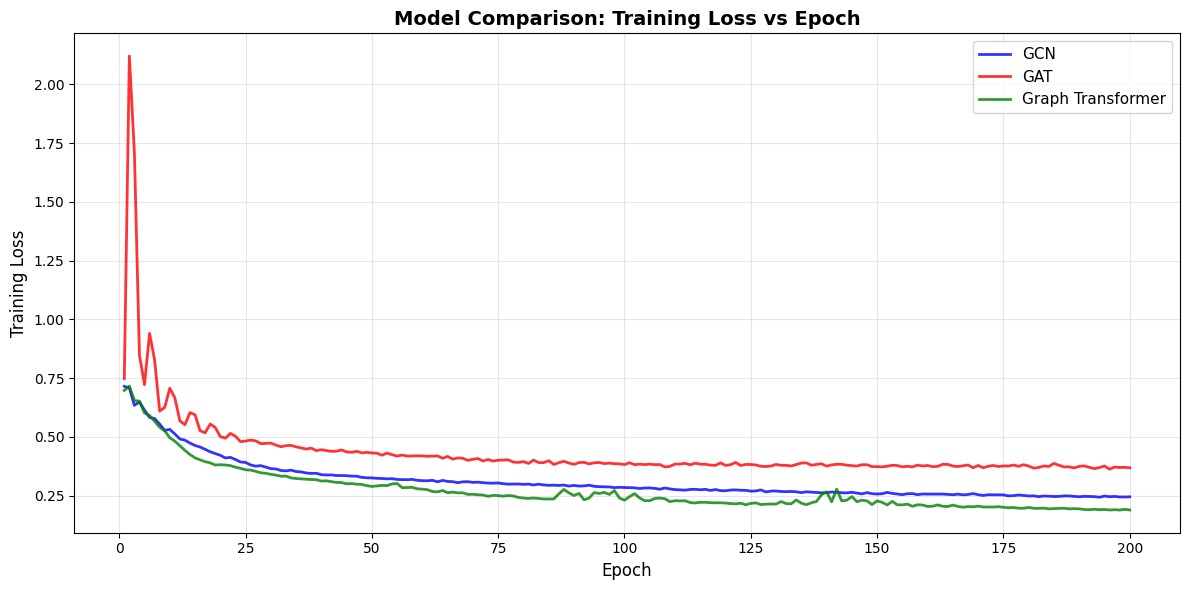


MODEL PERFORMANCE COMPARISON

GCN:
  Validation -> Acc: 0.8841, F1: 0.6470
  Test       -> Acc: 0.7356, F1: 0.2872

GAT:
  Validation -> Acc: 0.8930, F1: 0.6624
  Test       -> Acc: 0.7552, F1: 0.3004

GAT:
  Validation -> Acc: 0.8930, F1: 0.6624
  Test       -> Acc: 0.7552, F1: 0.3004

Graph Transformer:
  Validation -> Acc: 0.9386, F1: 0.7769
  Test       -> Acc: 0.8477, F1: 0.4024

Summary Table:
            Model  Val Accuracy   Val F1  Test Accuracy  Test F1
              GCN      0.884094 0.646969       0.735633 0.287239
              GAT      0.892959 0.662447       0.755189 0.300360
Graph Transformer      0.938618 0.776900       0.847690 0.402448

Graph Transformer:
  Validation -> Acc: 0.9386, F1: 0.7769
  Test       -> Acc: 0.8477, F1: 0.4024

Summary Table:
            Model  Val Accuracy   Val F1  Test Accuracy  Test F1
              GCN      0.884094 0.646969       0.735633 0.287239
              GAT      0.892959 0.662447       0.755189 0.300360
Graph Transformer      0.

<BarContainer object of 3 artists>

Text(0, 0.5, 'Test Accuracy')

Text(0.5, 1.0, 'Test Accuracy Comparison')

(0.0, 1.0)

Text(0, 0.7556328734253149, '0.7356')

Text(1, 0.7751889622075585, '0.7552')

Text(2, 0.8676904619076184, '0.8477')

<BarContainer object of 3 artists>

Text(0, 0.5, 'Test F1 Score')

Text(0.5, 1.0, 'Test F1 Score Comparison')

(0.0, 1.0)

Text(0, 0.30723920426977197, '0.2872')

Text(1, 0.32036002057260415, '0.3004')

Text(2, 0.42244763473758534, '0.4024')

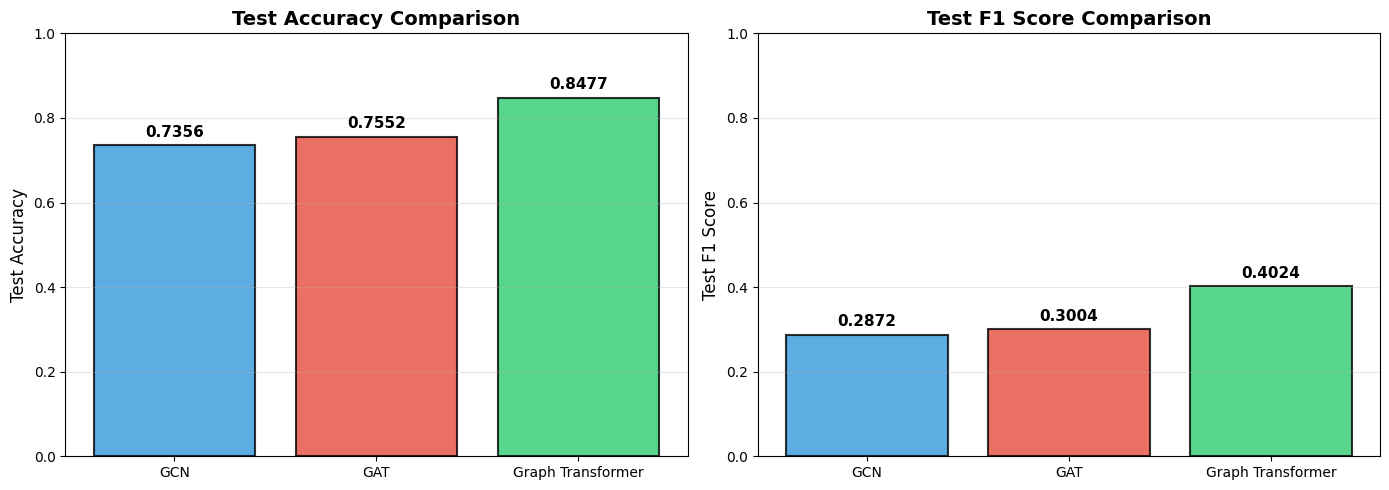


FINAL TRAINING LOSS (Last Epoch):
GCN:               0.244592
GAT:               0.368069
Graph Transformer: 0.188565

🏆 BEST MODEL: Graph Transformer
   Test Accuracy: 0.8477
   Test F1 Score: 0.4024

PERFORMANCE DIFFERENCES (relative to best model):
GCN:
  Accuracy difference: -0.1121 (-11.21%)
  F1 difference:       -0.1152 (-11.52%)
GAT:
  Accuracy difference: -0.0925 (-9.25%)
  F1 difference:       -0.1021 (-10.21%)


In [ ]:
# ============================================
# PERFORMANCE COMPARISON: GCN vs GAT vs Transformer
# ============================================

# 1) Compare Training Loss Curves
print("\n" + "="*60)
print("MODEL COMPARISON: TRAINING LOSS")
print("="*60)

fig, ax = plt.subplots(1, 1, figsize=(12, 6))
ax.plot(range(1, len(gcn_loss_history) + 1), gcn_loss_history, 'b-', linewidth=2, label='GCN', alpha=0.8)
ax.plot(range(1, len(gat_loss_history) + 1), gat_loss_history, 'r-', linewidth=2, label='GAT', alpha=0.8)
ax.plot(range(1, len(transformer_loss_history) + 1), transformer_loss_history, 'g-', linewidth=2, label='Graph Transformer', alpha=0.8)
ax.set_xlabel('Epoch', fontsize=12)
ax.set_ylabel('Training Loss', fontsize=12)
ax.set_title('Model Comparison: Training Loss vs Epoch', fontsize=14, fontweight='bold')
ax.legend(fontsize=11, loc='best')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 2) Compute final metrics for all models on test set
print("\n" + "="*60)
print("MODEL PERFORMANCE COMPARISON")
print("="*60)

models_dict = {
    'GCN': gcn,
    'GAT': gat,
    'Graph Transformer': transformer
}

results = []
for name, model in models_dict.items():
    test_acc, test_f1 = eval_on_mask(model, data, data.test_mask)
    results.append({
        'Model': name,
        'Test Accuracy': test_acc,
        'Test F1': test_f1
    })
    print(f"\n{name}:")
    print(f"  Test -> Acc: {test_acc:.4f}, F1: {test_f1:.4f}")

# Create DataFrame for easy comparison
df_results = pd.DataFrame(results)
print("\n" + "="*60)
print("Summary Table:")
print("="*60)
print(df_results.to_string(index=False))

# 3) Bar chart comparison of Test Accuracy and F1
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

models = df_results['Model'].values
test_accs = df_results['Test Accuracy'].values
test_f1s = df_results['Test F1'].values

colors = ['#3498db', '#e74c3c', '#2ecc71']

# Test Accuracy
ax1.bar(models, test_accs, color=colors, alpha=0.8, edgecolor='black', linewidth=1.5)
ax1.set_ylabel('Test Accuracy', fontsize=12)
ax1.set_title('Test Accuracy Comparison', fontsize=14, fontweight='bold')
ax1.set_ylim([0, 1.0])
ax1.grid(axis='y', alpha=0.3)
for i, v in enumerate(test_accs):
    ax1.text(i, v + 0.02, f'{v:.4f}', ha='center', fontsize=11, fontweight='bold')

# Test F1 Score
ax2.bar(models, test_f1s, color=colors, alpha=0.8, edgecolor='black', linewidth=1.5)
ax2.set_ylabel('Test F1 Score', fontsize=12)
ax2.set_title('Test F1 Score Comparison', fontsize=14, fontweight='bold')
ax2.set_ylim([0, 1.0])
ax2.grid(axis='y', alpha=0.3)
for i, v in enumerate(test_f1s):
    ax2.text(i, v + 0.02, f'{v:.4f}', ha='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

# 4) Final loss comparison (last epoch)
print("\n" + "="*60)
print("FINAL TRAINING LOSS (Last Epoch):")
print("="*60)
print(f"GCN:               {gcn_loss_history[-1]:.6f}")
print(f"GAT:               {gat_loss_history[-1]:.6f}")
print(f"Graph Transformer: {transformer_loss_history[-1]:.6f}")

# 5) Identify best model
best_model_idx = df_results['Test F1'].idxmax()
best_model_name = df_results.loc[best_model_idx, 'Model']
best_f1 = df_results.loc[best_model_idx, 'Test F1']
best_acc = df_results.loc[best_model_idx, 'Test Accuracy']

print("\n" + "="*60)
print(f"🏆 BEST MODEL: {best_model_name}")
print(f"   Test Accuracy: {best_acc:.4f}")
print(f"   Test F1 Score: {best_f1:.4f}")
print("="*60)

# 6) Compute performance differences
print("\n" + "="*60)
print("PERFORMANCE DIFFERENCES (relative to best model):")
print("="*60)
for idx, row in df_results.iterrows():
    if row['Model'] != best_model_name:
        acc_diff = row['Test Accuracy'] - best_acc
        f1_diff = row['Test F1'] - best_f1
        print(f"{row['Model']}:")
        print(f"  Accuracy difference: {acc_diff:+.4f} ({acc_diff*100:+.2f}%)")
        print(f"  F1 difference:       {f1_diff:+.4f} ({f1_diff*100:+.2f}%)")


In [ ]:
# ============================================
# SAVE GRAPH TRANSFORMER MODEL FOR INFERENCE
# ============================================

import os

# Create models directory if it doesn't exist
os.makedirs('models', exist_ok=True)

# Save Graph Transformer model
model_path = 'models/graph_transformer.pt'
torch.save({
    'model_state_dict': transformer.state_dict(),
    'input_dim': input_dim,
    'hidden_dim': hidden_dim,
    'num_classes': num_classes,
    'dropout': 0.5,
    'heads': 4,
    'model_config': {
        'model_type': 'GraphTransformer',
        'train_samples': train_mask.sum().item(),
        'test_samples': test_mask.sum().item(),
        'test_accuracy': ta,
        'test_f1': tf1
    },
    'scaler_params': {
        'feature_min': scaler.data_min_.tolist(),
        'feature_max': scaler.data_max_.tolist(),
        'feature_names': feat_cols
    }
}, model_path)

print(f"✅ Graph Transformer model saved to: {model_path}")
print(f"   Input dim: {input_dim}")
print(f"   Hidden dim: {hidden_dim}")
print(f"   Output classes: {num_classes}")
print(f"   Test Accuracy: {ta:.4f}")
print(f"   Test F1 Score: {tf1:.4f}")


✅ Graph Transformer model saved to: models/graph_transformer.pt
   Input dim: 182
   Hidden dim: 64
   Output classes: 2
   Test Accuracy: 0.8477
   Test F1 Score: 0.4024
